# 02 — Run a fly brain

Every neuron becomes a leaky integrate-and-fire unit (Shiu et al. 2024 parameters), every synapse a signed weight,
and the whole thing steps at 0.1 ms on the GPU. Read `docs/02-lif-brain.md` for the model and how we calibrated it.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, polars as pl, torch
from flyhigh.data.connectome import Connectome
from flyhigh.brain.lif import LIFBrain
from flyhigh.brain.stimulus import PoissonActivation
from flyhigh.brain.recorder import SpikeRecorder
import matplotlib as mpl, matplotlib.pyplot as plt
# dataviz conventions: fixed categorical order, single-hue sequential, thin marks, recessive grid
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
                     "axes.prop_cycle": mpl.cycler(color=C), "lines.linewidth": 2, "font.size": 10})
c = Connectome.load("../data/raw")
MAX_HZ = 1000 / 2.3   # refractory ceiling

def run(activations, silence=None, duration_ms=1000, record=None, seed=0):
    torch.manual_seed(seed)
    brain = LIFBrain.for_male_cns(c, device="cuda")
    if silence is not None: brain.silence(silence)
    rec = brain.run(int(duration_ms / 0.1), stimuli=[PoissonActivation(i, hz) for i, hz in activations],
                    recorder=SpikeRecorder(neuron_idx=record))
    return rec, rec.rates(duration_ms)[0]

def top_types(rates, exclude=()):
    df = c.neurons.with_columns(pl.Series("rate", rates)).filter(pl.col("rate") > 5)
    df = df.filter(~pl.col("type").str.contains("|".join(f"^{t}" for t in exclude) or "^$").fill_null(False))
    return df.group_by("type", "nt").agg(pl.len().alias("cells"), pl.col("rate").mean().round(0).alias("Hz")).sort("Hz", descending=True)

## 1. A quiet brain
With no input the model is silent: there is no spontaneous activity, so everything you see later is caused by the input you give.

In [2]:
rec, r = run([], duration_ms=300)
print("spikes with no input:", rec.counts.sum().item())

spikes with no input: 0


## 2. Taste → feeding
Activate the 51 sugar-sensing labellar neurons (`LB3a/b/c`) at 200 Hz — the model's stand-in for putting sugar on the fly's mouth — and watch who fires.

In [3]:
lb3 = c.ids_by_type(r"^LB3[abc]$"); mn9 = c.ids_by_type(r"^MN9$")
rec, r = run([(lb3, 200)], record=None)      # record every spike (fine for 1 s)
print(f"active neurons: {(rec.counts[0] > 0).sum().item():,} of {c.n_neurons:,}   MN9 (feeding motor neuron) L/R: {r[mn9[0]]:.0f} / {r[mn9[1]]:.0f} Hz")
top_types(r, exclude=("LB3",)).head(12)

active neurons: 926 of 165,122   MN9 (feeding motor neuron) L/R: 12 / 0 Hz


type,nt,cells,Hz
str,str,u32,f64
"""GNG038""","""gaba""",2,246.0
"""GNG042""","""gaba""",2,225.0
"""GNG175""","""gaba""",2,219.0
"""ANXXX462a""","""acetylcholine""",2,202.0
"""GNG229""","""gaba""",2,192.0
…,…,…,…
"""AN13B002""","""gaba""",2,154.0
"""GNG232""","""acetylcholine""",2,152.0
"""GNG132""","""acetylcholine""",2,134.0


Those are the paper's second-order taste neurons — GNG038, *Clavicle* (`ANXXX462a`), *Quasimodo* (`GNG042`), GNG175 — and the descending neuron DNg67.
A raster shows the timing: the GRNs (bottom) drive the interneurons within 5 ms, and MN9 fires sparsely.

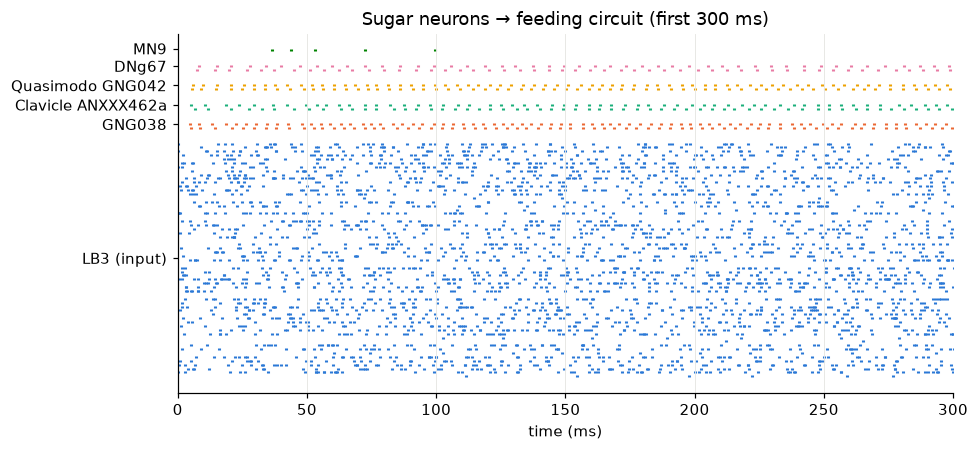

In [4]:
spk = rec.to_polars().join(c.neurons.select(pl.col("index").alias("neuron"), "type"), on="neuron")
groups = [("LB3 (input)", r"^LB3"), ("GNG038", r"^GNG038$"), ("Clavicle ANXXX462a", r"^ANXXX462a$"), ("Quasimodo GNG042", r"^GNG042$"), ("DNg67", r"^DNg67$"), ("MN9", r"^MN9$")]
fig, ax = plt.subplots(figsize=(9, 4.2))
y = 0; ticks = []
for i, (label, pat) in enumerate(groups):
    s = spk.filter(pl.col("type").str.contains(pat).fill_null(False))
    ids = {n: k for k, n in enumerate(sorted(s["neuron"].unique()))}
    ax.scatter(s["t_ms"], [y + ids[n] for n in s["neuron"]], s=2, color=C[i % len(C)], marker="|")
    ticks.append((y + len(ids) / 2, label)); y += max(len(ids), 1) + 3
ax.set_yticks([t for t, _ in ticks]); ax.set_yticklabels([l for _, l in ticks]); ax.set_xlim(0, 300); ax.set_xlabel("time (ms)")
ax.set_title("Sugar neurons → feeding circuit (first 300 ms)"); ax.grid(axis="y", visible=False)
plt.tight_layout()

## 3. Silencing a neuron
Connectome models are for *what-if* experiments. The gustatory paper predicts that **Clavicle** is a key relay to MN9. Silence it (its outgoing synapses set to zero) and compare.

In [5]:
clav = c.ids_by_type(r"^ANXXX462a$")
_, r_cut = run([(lb3, 200)], silence=clav)
print(f"MN9 rate: intact {r[mn9].mean():.1f} Hz   Clavicle silenced {r_cut[mn9].mean():.1f} Hz")

MN9 rate: intact 6.0 Hz   Clavicle silenced 5.5 Hz


At our calibration MN9 is barely above threshold, so this prediction does not reproduce cleanly (see `docs/02-lif-brain.md`). Honest modelling means reporting that.

## 4. Looming → escape
The circuit we will drive from a camera: looming-sensitive visual projection neurons **LC4 + LPLC2** synapse directly onto the **giant fiber** (`DNp01`).

In [6]:
lc4 = c.ids_by_type(r"^LC4$"); lplc2 = c.ids_by_type(r"^LPLC2$"); gf = c.ids_by_type(r"^DNp01$")
rec, r = run([(lc4, 100), (lplc2, 100)], duration_ms=300, record=None)
first = rec.to_polars().filter(pl.col("neuron").is_in(pl.Series(gf).implode()))["t_ms"].min()
print(f"giant fiber: first spike at {first} ms, rate L/R {r[gf[0]]:.0f}/{r[gf[1]]:.0f} Hz;  active neurons {(rec.counts[0] > 0).sum().item():,}")
top_types(r, exclude=("LC4", "LPLC2")).head(8)

giant fiber: first spike at 3.6 ms, rate L/R 220/247 Hz;  active neurons 2,026


type,nt,cells,Hz
str,str,u32,f64
"""DNp04""","""acetylcholine""",2,245.0
"""PVLP011""","""gaba""",2,240.0
"""DNp01""","""acetylcholine""",2,233.0
"""PVLP069""","""acetylcholine""",2,202.0
"""DNp103""","""acetylcholine""",2,167.0
"""PVLP130""","""gaba""",2,140.0
"""PVLP024""","""gaba""",3,139.0
"""AVLP531""","""gaba""",2,138.0


## 5. Which descending neurons respond?
Descending neurons are the brain's only output to the body. Rank them for the looming stimulus — this is the readout the motor module (M2) will use.

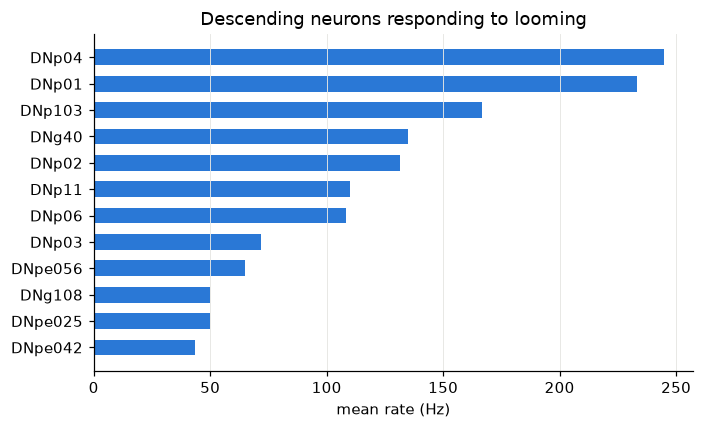

In [7]:
dn = c.neurons.filter(pl.col("superclass") == "descending_neuron").with_columns(pl.Series("rate", r[c.neurons.filter(pl.col("superclass") == "descending_neuron")["index"].to_numpy()]))
top = dn.group_by("type").agg(pl.col("rate").mean().alias("Hz")).sort("Hz", descending=True).head(12)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.barh(top["type"][::-1], top["Hz"][::-1], color=C[0], height=0.6)
ax.set_xlabel("mean rate (Hz)"); ax.set_title("Descending neurons responding to looming"); ax.grid(axis="y", visible=False)
plt.tight_layout()

## 6. How fast is it?
One step = 0.1 ms of brain time. Two agents cost the same as one because the batch is a tensor dimension.

In [8]:
import time
for A in (1, 2):
    b = LIFBrain.for_male_cns(c, n_agents=A, device="cuda")
    drive = (torch.rand(A, c.n_neurons, device="cuda") < 0.02).float() * 12.0
    for _ in range(100): b.step(ext_i=drive)
    torch.cuda.synchronize(); t = time.perf_counter()
    for _ in range(500): b.step(ext_i=drive)
    torch.cuda.synchronize(); ms = (time.perf_counter() - t) / 500 * 1e3
    print(f"{A} agent(s): {ms:.2f} ms per 0.1 ms step  →  {0.1 / ms:.3f}× real time")

1 agent(s): 1.95 ms per 0.1 ms step  →  0.051× real time


2 agent(s): 1.45 ms per 0.1 ms step  →  0.069× real time


## Try it
- Activate `DNp01` itself and see what happens downstream in the VNC (wing and leg motor neurons `MN*`).
- Change `200` Hz to `50` Hz in section 2: taste responses are graded.
- `run([(c.ids_by_type(r"^R1-R6$"), 20)])` — drive all photoreceptors; the optic lobe is a very different beast (M2).